# Part I — From Text to Prediction

## The North Star

An LLM is a **next-word predictor**. You give it "The cat sat on the" and it outputs a probability distribution over every possible next word — and "mat" gets a high score.

Two questions:
1. **What does it mean to predict?** How does a machine guess the next thing in a sequence?
2. **What is a "word" to a machine?** Computers work with numbers. How do we turn language into something mathematical?

This notebook answers both questions through six chapters, building from linear regression to a complete (if naive) language model.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from llmkit import data, viz
from llmkit.solutions import ch01_regression, ch02_onehot, ch03_logistic, ch04_word2vec, ch05_mlp, ch06_bpe

# Set random seed for reproducibility
np.random.seed(42)

print("Setup complete!")

Setup complete!


---

# Chapter 1: Linear Regression

**Track:** Prediction  
**Question:** Can we predict the next number in a sequence?

---

## 1.1 Linear Regression

Forget words entirely. Start with something pure: given the sequence 2, 4, 6, ?, can we learn the pattern? This is supervised learning in its simplest form.

To learn any pattern, we need three things: a **model** (a function with adjustable parameters), a **loss function** (a single number measuring how wrong we are), and **gradient descent** (a rule for adjusting parameters to reduce the loss). These three components never change as we build more complex systems. Only the model gets more complex.

---

**Model** — a function with two adjustable knobs: slope and intercept. Every straight-line relationship can be written as:

$$\hat{y} = wx + b$$

Here $wx$ scales the input by the weight — a large $w$ makes a steep line, $w = 0$ makes a flat one. The bias $b$ shifts the whole line up or down independently of $x$. Together they define any line in the plane.

---

**Loss (Mean Squared Error)** — a single number capturing how wrong all predictions are at once. We square the error for two reasons: large mistakes get penalized far more than small ones (a prediction 10 off contributes 100× more than one that's 1 off), and the function is smooth everywhere — unlike absolute error $|\hat{y} - y|$, which has a sharp kink at 0 that makes gradients messy.

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

---

**Gradients** — the direction and magnitude each parameter should change to reduce the loss. Applying the chain rule to differentiate $(\hat{y}_i - y_i)^2$ with respect to $w$: the outer derivative gives $2(\hat{y}_i - y_i)$, and $\partial \hat{y}/\partial w = x_i$. So a larger input causes a larger change in the prediction, and therefore a larger gradient contribution.

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i) \cdot x_i \qquad \frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

---

**Parameter update** — move each parameter opposite to its gradient. The gradient points toward increasing loss; we go the other way.

$$w \leftarrow w - \alpha \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

The learning rate $\alpha$ controls step size. Too large: we overshoot the minimum and bounce around. Too small: training takes far more steps than necessary. Values of 0.001–0.1 are typical.

---

**By hand — one complete gradient descent step:**

```
Inputs:  x = 2,  y = 5,  w = 1,  b = 0,  α = 0.01

Forward:
  ŷ    = 1×2 + 0       =  2
  loss = (2 − 5)²      =  9

Gradients:
  grad_w = 2×(2−5)×2   = −12   ← negative: w should increase
  grad_b = 2×(2−5)     =  −6

Update:
  w ← 1 − 0.01×(−12)  =  1.12  ✓ moved in the right direction
  b ← 0 − 0.01×(−6)   =  0.06  ✓
```

---

**By hand — two steps with multiple data points:**

The example above shows a single data point. In practice, you have many points and must average the loss and gradients across all of them. Here's how it works with 3 data points over 2 iterations:

```
Dataset:  x = [1, 2, 3],  y = [3, 5, 7]  (true model: y = 2x + 1)
Initial:  w = 0,  b = 0,  α = 0.1

═══════════════════════════════════════════════════════════════════
ITERATION 1
═══════════════════════════════════════════════════════════════════

Forward pass (compute predictions for all points):
  ŷ₁ = 0×1 + 0 = 0
  ŷ₂ = 0×2 + 0 = 0
  ŷ₃ = 0×3 + 0 = 0

Compute loss (average squared error across all points):
  error₁ = (0 − 3)² = 9
  error₂ = (0 − 5)² = 25
  error₃ = (0 − 7)² = 49

  loss = (9 + 25 + 49) / 3 = 83 / 3 = 27.67

Compute gradients (average across all points):
  For w:
    ∂L/∂w₁ = 2×(0−3)×1 = −6
    ∂L/∂w₂ = 2×(0−5)×2 = −20
    ∂L/∂w₃ = 2×(0−7)×3 = −42
    grad_w = (−6 + −20 + −42) / 3 = −68 / 3 = −22.67

  For b:
    ∂L/∂b₁ = 2×(0−3) = −6
    ∂L/∂b₂ = 2×(0−5) = −10
    ∂L/∂b₃ = 2×(0−7) = −14
    grad_b = (−6 + −10 + −14) / 3 = −30 / 3 = −10.0

Update parameters:
  w ← 0 − 0.1×(−22.67) = 2.27   ✓ moving toward true w = 2
  b ← 0 − 0.1×(−10.0)  = 1.0    ✓ reached true b = 1 in one step!

═══════════════════════════════════════════════════════════════════
ITERATION 2 (parameters carry over from iteration 1)
═══════════════════════════════════════════════════════════════════

Forward pass (use updated w and b):
  ŷ₁ = 2.27×1 + 1.0 = 3.27
  ŷ₂ = 2.27×2 + 1.0 = 5.54
  ŷ₃ = 2.27×3 + 1.0 = 7.81

Compute loss:
  error₁ = (3.27 − 3)² = 0.07
  error₂ = (5.54 − 5)² = 0.29
  error₃ = (7.81 − 7)² = 0.66

  loss = (0.07 + 0.29 + 0.66) / 3 = 1.02 / 3 = 0.34  ✓ much lower!

Compute gradients:
  For w:
    ∂L/∂w₁ = 2×(3.27−3)×1 = 0.54
    ∂L/∂w₂ = 2×(5.54−5)×2 = 2.16
    ∂L/∂w₃ = 2×(7.81−7)×3 = 4.86
    grad_w = (0.54 + 2.16 + 4.86) / 3 = 7.56 / 3 = 2.52

  For b:
    ∂L/∂b₁ = 2×(3.27−3) = 0.54
    ∂L/∂b₂ = 2×(5.54−5) = 1.08
    ∂L/∂b₃ = 2×(7.81−7) = 1.62
    grad_b = (0.54 + 1.08 + 1.62) / 3 = 3.24 / 3 = 1.08

Update parameters:
  w ← 2.27 − 0.1×2.52 = 2.02   ✓ closer to true w = 2
  b ← 1.0  − 0.1×1.08 = 0.89   ✓ now slightly below true b = 1
```

**Key pattern:** In each iteration:
1. Compute predictions for ALL data points
2. Sum up losses/gradients across ALL points, then divide by n
3. Update parameters once using the averaged gradients
4. Repeat with the new parameter values

In code, NumPy handles this automatically with vectorized operations — `y_pred = w * x + b` computes all predictions at once, and `sum()` or `np.sum()` gives you the total.



## 1.4 Exercise

Implement gradient descent for linear regression.

In [2]:
# Generate training data
x, y = data.generate_linear_sequence(n=100, slope=2, intercept=5, noise=1.0)

def your_gradient_descent(x, y, learning_rate=0.01, n_iterations=100):
    """Implement gradient descent for linear regression"""
    # Initialize parameters
    w = 0.0
    b = 0.0
    
    w_history = []
    b_history = []
    loss_history = []
    
    for i in range(n_iterations):
        # TODO: Forward pass - compute predictions
        y_pred = w * x + b
        
        # TODO: Compute loss (MSE)
        loss = sum((y - y_pred)**2)/len(y)
        
        # TODO: Compute gradients
        n = len(x)
        error = ...
        grad_w =
        grad_b = ...
        
        # TODO: Update parameters
        w = ...
        b = ...
        
        # Record history
        w_history.append(w)
        b_history.append(b)
        loss_history.append(loss)
    
    return {
        'x': x,
        'y': y,
        'w_history': np.array(w_history),
        'b_history': np.array(b_history),
        'loss_history': np.array(loss_history),
        'final_w': w,
        'final_b': b
    }

## 1.5 Verify & Compare

In [3]:
# Your implementation
your_result = your_gradient_descent(x, y, learning_rate=0.01, n_iterations=100)

# Reference implementation
reference_result = ch01_regression.gradient_descent(x, y, learning_rate=0.01, n_iterations=100)

# Compare results
viz.compare(your_result['final_w'], reference_result['final_w'])
viz.compare(your_result['final_b'], reference_result['final_b'])

# Use reference if not implemented
your_result = viz.resolve(your_result, reference_result)

print(f"\nYour final model: y = {your_result['final_w']:.2f}x + {your_result['final_b']:.2f}")
print(f"Reference model: y = {reference_result['final_w']:.2f}x + {reference_result['final_b']:.2f}")
print(f"True model: y = 2.00x + 5.00")

[NOT IMPLEMENTED] Found ... placeholder
[NOT IMPLEMENTED] Found ... placeholder
[SKIPPED] Using reference implementation

Your final model: y = 2.25x + 4.31
Reference model: y = 2.25x + 4.31
True model: y = 2.00x + 5.00


## 1.6 Visualize

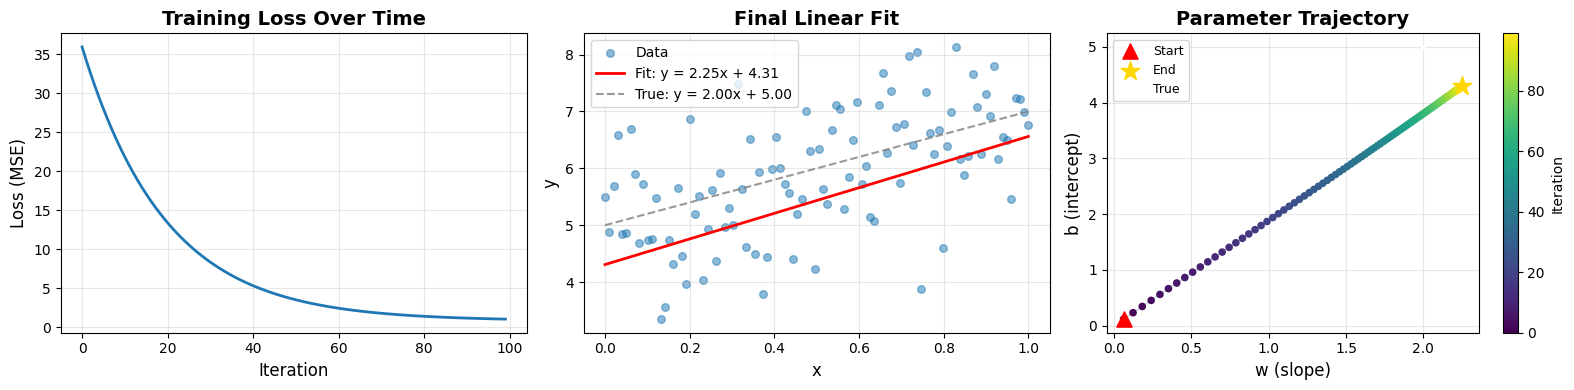

In [4]:
# From this point on, use reference implementation to prevent cascading errors
viz.plot_gradient_descent(reference_result, true_w=2.0, true_b=5.0)

**Key Takeaway:**
> Prediction = find parameters that minimize a loss function via gradient descent.

---

# Chapter 2: One-Hot Encoding

**Track:** Representation  
**Question:** How do we turn words into numbers?

---

## 2.1 One-Hot Encoding

The simplest possible representation: assign each word a unique index, then build a binary vector with a 1 at that index and 0s everywhere else.

If our vocabulary is [the, cat, sat, on, mat], then "cat" becomes [0, 1, 0, 0, 0]. That's it. No more information is encoded — and that limitation is the entire point of this chapter. We build on these vectors first precisely because their failures will motivate everything that follows.

---

**Encoding function** — map each word to a unique standard basis vector. Create a zero vector of length $|V|$ and place a 1 at the word's index position.

$$\text{onehot}(w_i) = \mathbf{e}_i \in \mathbb{R}^{|V|}, \qquad \mathbf{e}_i[j] = \begin{cases} 1 & \text{if } j = i \\ 0 & \text{otherwise} \end{cases}$$

Each word "owns" exactly one dimension. All other dimensions are silent. The subscript $i$ is the word's position in the vocabulary list — an arbitrary assignment, not semantic information.

**By hand — constructing two one-hot vectors:**

```
Vocabulary: [the, cat, sat, on, mat]  (size 5)

Encode "cat":
  index("cat") = 1
  start:          [0, 0, 0, 0, 0]
  set position 1: [0, 1, 0, 0, 0]  ✓

Encode "mat":
  index("mat") = 4
  start:          [0, 0, 0, 0, 0]
  set position 4: [0, 0, 0, 0, 1]  ✓
```

---

**Euclidean distance** — how far apart any two one-hot vectors are. Subtracting two distinct one-hot vectors leaves exactly a $+1$ at one position and a $-1$ at another, zeros everywhere else. Squaring and summing: $1^2 + (-1)^2 = 2$, so the distance is always $\sqrt{2} \approx 1.414$, regardless of which two words we compare.

$$\|\mathbf{e}_i - \mathbf{e}_j\|_2 = \sqrt{2} \quad \text{for all } i \neq j$$

This means "cat" and "dog" are as far apart as "cat" and "justice." The geometry carries zero semantic information — every word sits at a corner of a high-dimensional hypercube, and all corners are equidistant from one another. This is the fundamental limitation that motivates dense embeddings in Chapter 4.


## 2.4 Exercise

Implement one-hot encoding.

In [5]:
# Generate simple text
text, vocab = data.generate_simple_text(n_words=50, vocab_size=10)

def your_build_vocabulary(text):
    """Build vocabulary from text"""
    # TODO: Get unique words and sort them
    vocab = ...
    
    # TODO: Create word-to-index mapping
    word2idx = ...
    
    # TODO: Create index-to-word mapping
    idx2word = ...
    
    return vocab, word2idx, idx2word

def your_one_hot_encode(word, word2idx):
    """Encode a word as one-hot vector"""
    vocab_size = len(word2idx)
    
    # TODO: Create zero vector of size vocab_size
    vector = ...
    
    # TODO: Set 1 at the word's index
    # ...
    
    return vector

# Test your implementation
try:
    vocab, word2idx, idx2word = your_build_vocabulary(text)
    print(f"Vocabulary size: {len(vocab)}")
    print(f"Vocabulary: {vocab[:5]}...")
    word = vocab[0]
    encoded = your_one_hot_encode(word, word2idx)
    print(f"\n'{word}' encoded: {encoded}")
except (TypeError, ValueError):
    print("[NOT IMPLEMENTED]")
    word = text[0]
    encoded = ...

[NOT IMPLEMENTED]


## 2.5 Verify & Compare

In [6]:
# Reference implementation
ref_vocab, ref_word2idx, ref_idx2word = ch02_onehot.build_vocabulary(text)
ref_encoded = ch02_onehot.one_hot_encode(word, ref_word2idx)

# Compare
encoded = viz.resolve(encoded, ref_encoded)
viz.compare(encoded, ref_encoded)

# From now on, use reference
vocab, word2idx, idx2word = ref_vocab, ref_word2idx, ref_idx2word

[SKIPPED] Using reference implementation
[PASS] Results match!


## 2.6 Visualize

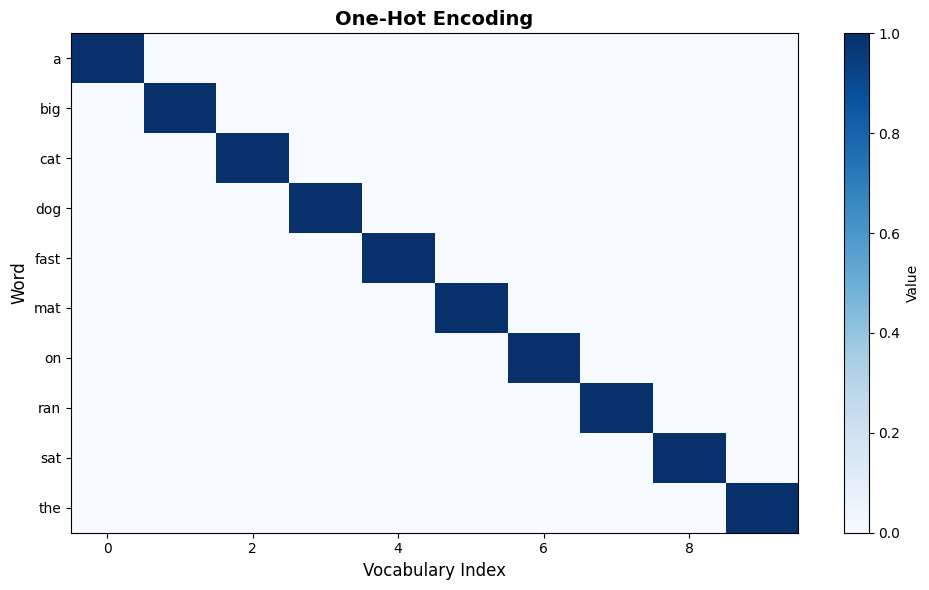

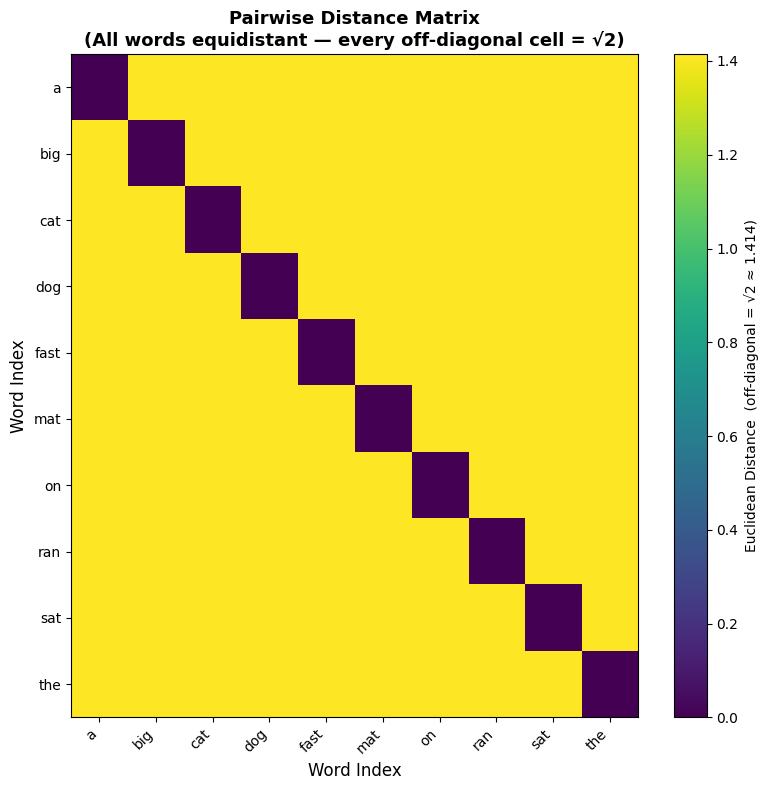

In [7]:
# Encode all words in vocabulary
vectors = ch02_onehot.one_hot_encode_sequence(vocab, word2idx)

# Visualize as heatmap
viz.plot_onehot_heatmap(vectors, vocab)

# Show that all words are equidistant
viz.plot_distance_matrix(vectors, vocab)

**Key Takeaway:**
> We have numbers now. They are terrible numbers, but they are numbers.

---

# Chapter 3: Logistic Regression

**Track:** Prediction + Representation  
**Question:** Can we predict the next word?

---

## 3.1 Logistic Regression

We have number representations (one-hot) and we know how to train a model (regression). Now combine them: given a one-hot input word, output a probability distribution over the entire vocabulary for what the next word should be.

Instead of predicting a single number, we output a score for every word, then normalize those scores into probabilities. This is the conceptual skeleton of an LLM — a transformer is just this same pipeline with massively upgraded components at every step.

---

**Logits** — a linear map from the input word to a score for every word in the vocabulary.

$$\underbrace{\mathbf{z}}_{(|V|,)} = \underbrace{\mathbf{x}}_{(|V|,)}\underbrace{W}_{(|V|,\,|V|)} + \underbrace{\mathbf{b}}_{(|V|,)}$$

Since $\mathbf{x}$ is one-hot, the matrix multiplication $\mathbf{x}W$ simply *selects one row of $W$* — the row corresponding to the input word's index. No actual multiplication happens for any other row. The matrix $W$ is a learned table of next-word scores, and the one-hot vector is an efficient key to look up one row at a time.

---

**Softmax** — converts the raw scores into a valid probability distribution. We need every output to be positive and all outputs to sum to 1. Exponentiating guarantees positivity (since $e^z > 0$ for any $z$); dividing by the total sum normalizes.

$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{|V|} e^{z_j}}$$

The ordering of scores is preserved — the word with the highest logit still gets the highest probability. Softmax amplifies differences: a logit gap of 2 produces a probability ratio of $e^2 \approx 7.4$.

---

**Cross-entropy loss** — measures how surprised we are by the true answer. We want 0 loss when very confident and correct ($p_\text{true} \to 1$), and large loss when confident but wrong ($p_\text{true} \to 0$).

$$L = -\log(p_{\text{true}})$$

Why $-\log$ rather than something simpler like $(1 - p)$?

| $p_\text{true}$ | Loss with $(1-p)$ | Loss with $-\log(p)$ |
|:-:|:-:|:-:|
| 0.99 (confident, correct) | 0.01 | 0.01 |
| 0.50 (uncertain) | 0.50 | 0.69 |
| 0.01 (confident, wrong) | 0.99 | **4.6** |

$-\log(p)$ punishes low-confidence correct predictions far more aggressively. It's also the Shannon "surprise": if you were nearly certain, hearing the true answer is unsurprising (low loss). If you were confidently wrong, it's very surprising (high loss).

---

**Gradient** — the combined softmax + cross-entropy gradient simplifies elegantly. The chain rule cancels most intermediate terms and leaves just our predicted distribution minus the one-hot correct answer:

$$\frac{\partial L}{\partial \mathbf{z}} = \mathbf{p} - \mathbf{y}_{\text{true}}$$

For the true word, the gradient is $p_\text{true} - 1 < 0$ — nudge its score up. For every other word, the gradient is $p_i > 0$ — nudge their scores down. This is exactly what training should do.

---

**By hand — forward pass and gradient:**

```
Vocab: [the, cat, sat],  input: "cat",  true next word: "sat" (index 2)

Forward:
  logits z = [2.0, 1.0, 0.5]
  exp(z)   = [7.39, 2.72, 1.65]   sum = 11.75
  probs p  = [0.63, 0.23, 0.14]

Loss:
  L = −log(p[2]) = −log(0.14) = 1.97   ← high: model is not confident in "sat"

Gradient:
  ∂L/∂z = p − y = [0.63, 0.23, 0.14 − 1] = [0.63, 0.23, −0.86]
                                                         ↑ push "sat" score up
```


## 3.4 Exercise

Implement softmax regression for next-word prediction.

In [8]:
# Generate next-word training pairs
text, vocab = data.generate_simple_text(n_words=200, vocab_size=10)
contexts, targets = data.generate_next_word_pairs(text, window_size=1)

# Build vocabulary
vocab, word2idx, idx2word = ch02_onehot.build_vocabulary(text)
vocab_size = len(vocab)

def your_softmax(logits):
    """Apply softmax to logits"""
    # TODO: Subtract max for numerical stability
    logits_shifted = ...
    
    # TODO: Compute exp
    exp_logits = ...
    
    # TODO: Normalize to get probabilities
    probs = ...
    
    return probs

def your_cross_entropy(probs, target_idx):
    """Compute cross-entropy loss"""
    # TODO: Return negative log probability of true class
    loss = ...
    
    return loss

# Test
test_logits = np.array([2.0, 1.0, 0.1, 0.5])
try:
    test_probs = your_softmax(test_logits)
    print(f"Logits: {test_logits}")
    print(f"Probabilities: {test_probs}")
    print(f"Sum of probs: {test_probs.sum():.4f} (should be 1.0)")
    test_loss = your_cross_entropy(test_probs, 0)
    print(f"\nLoss when true class is 0: {test_loss:.4f}")
except (AttributeError, TypeError):
    print("[NOT IMPLEMENTED]")
    test_probs = ...
    test_loss = ...

Logits: [2.  1.  0.1 0.5]
Probabilities: Ellipsis
[NOT IMPLEMENTED]


## 3.5 Verify & Compare

In [9]:
# Compare softmax
ref_probs = ch03_logistic.softmax(test_logits)
test_probs = viz.resolve(test_probs, ref_probs)
viz.compare(test_probs, ref_probs)

# Compare cross-entropy
ref_loss = ch03_logistic.cross_entropy_loss(ref_probs, 0)
test_loss = viz.resolve(test_loss, ref_loss)
viz.compare(test_loss, ref_loss)

# Train a full model with reference implementation
print("\nTraining logistic regression model...")
X_train = ch02_onehot.one_hot_encode_sequence([c[0] for c in contexts], word2idx)
y_train = np.array([word2idx[t] for t in targets])

model, loss_history = ch03_logistic.train_logistic_regression(
    X_train, y_train, vocab_size, learning_rate=0.1, n_epochs=20
)

[SKIPPED] Using reference implementation
[PASS] Results match!
[SKIPPED] Using reference implementation
[PASS] Results match!

Training logistic regression model...
Epoch 2/20, Loss: 2.2862
Epoch 4/20, Loss: 2.2303
Epoch 6/20, Loss: 2.2047
Epoch 8/20, Loss: 2.1917
Epoch 10/20, Loss: 2.1843
Epoch 12/20, Loss: 2.1796
Epoch 14/20, Loss: 2.1764
Epoch 16/20, Loss: 2.1740
Epoch 18/20, Loss: 2.1722
Epoch 20/20, Loss: 2.1707


## 3.6 Visualize

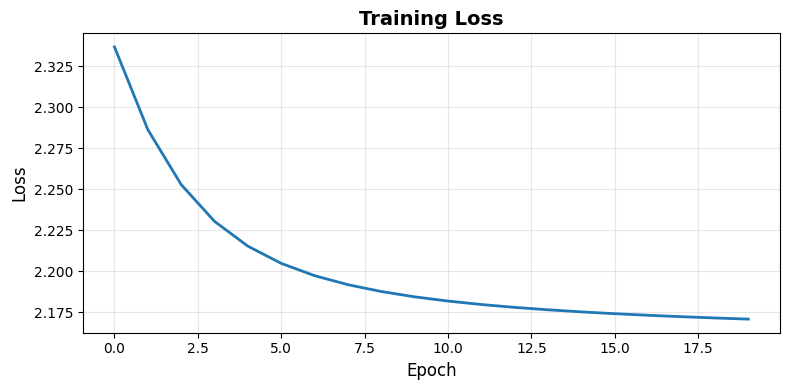


Given context word: 'a'
Top 3 predicted next words:
  ran: 0.214
  cat: 0.203
  dog: 0.153


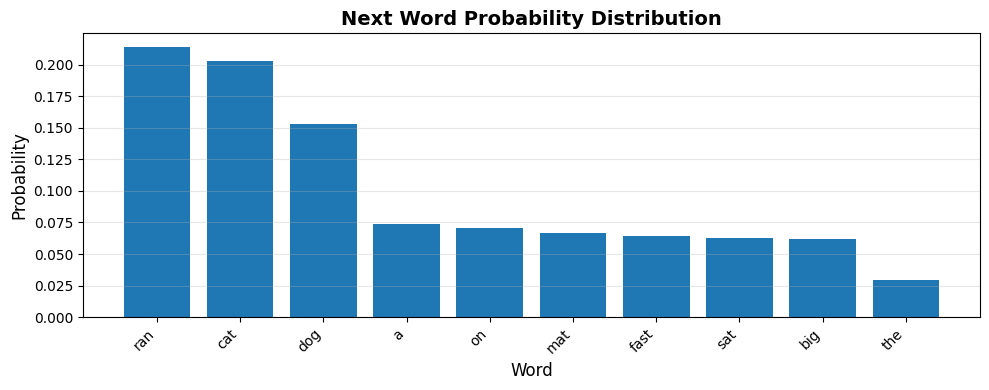

In [10]:
# Plot training loss
viz.plot_loss_curve(loss_history, xlabel="Epoch")

# Predict next word given a context
test_word = vocab[0]
test_input = ch02_onehot.one_hot_encode(test_word, word2idx)
probs = model.predict(test_input)

print(f"\nGiven context word: '{test_word}'")
print(f"Top 3 predicted next words:")
top_indices = np.argsort(probs)[-3:][::-1]
for idx in top_indices:
    print(f"  {vocab[idx]}: {probs[idx]:.3f}")

# Visualize probability distribution
viz.plot_probability_dist(probs, vocab)

**Key Takeaway:**
> We can predict words now, but our word representations carry no meaning.

---

# Chapter 4: Word2Vec (Dense Embeddings)

**Track:** Representation  
**Question:** What if we let the network learn better representations?

---

## 4.1 Word2Vec (Dense Embeddings)

One-hot vectors are sparse and meaningless — "cat" and "dog" are as far apart as "cat" and "justice." We want a representation where the geometry itself encodes meaning.

The key insight is the **distributional hypothesis**: words that appear in similar contexts have similar meanings. "Cat" and "dog" both appear near "pet," "food," "vet." If we train a model to predict words from their context (or vice versa), the internal representation it learns will naturally cluster semantically similar words together.

We go from $|V|$-dimensional sparse binary vectors to $d$-dimensional dense vectors — typically $d \approx 100$–$300$ — where direction and proximity encode semantic relationships.

---

**CBOW (Continuous Bag of Words)** — predict the center word from its surrounding context. We average the context word vectors into a single fixed-size representation, then project to vocabulary scores.

$$\underbrace{\mathbf{h}}_{(d,)} = \frac{1}{|C|} \sum_{w \in C} \mathbf{E}[w], \qquad \underbrace{\mathbf{z}}_{(|V|,)} = \underbrace{\mathbf{h}}_{(d,)}\underbrace{W_{\text{out}}}_{(d,\,|V|)}, \qquad p(w_{\text{center}} | C) = \text{softmax}(\mathbf{z})$$

Averaging gives a fixed-size $d$-dimensional vector regardless of how many context words there are. It's also order-invariant: "cat sat on" and "on sat cat" produce the same $\mathbf{h}$. We lose word order, but gain a simple trainable representation. We'll recover order later with attention.

---

**Skip-gram** — the reverse: predict each context word from the center word. One embedding lookup in, many predictions out.

$$\underbrace{\mathbf{h}}_{(d,)} = \mathbf{E}[w_{\text{center}}], \qquad p(w_{\text{context}} | w_{\text{center}}) = \text{softmax}(\mathbf{h}W_{\text{out}})$$

Skip-gram generates more training pairs per token than CBOW (one center word predicts multiple context words), giving a stronger gradient signal especially for rare words.

---

**Cosine similarity** — measures semantic closeness independently of how much a word was trained on. Frequent words get their embeddings updated more often, which inflates their $\ell_2$ norm — not because they are more "central" semantically, but because they appear more. Cosine similarity removes magnitude entirely; it measures only the angle between two vectors.

$$\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|} = \cos\theta \in [-1, 1]$$

A similarity of $+1$ means vectors point in the same direction (near-synonyms). $0$ means orthogonal (unrelated). $-1$ means opposite directions (potential antonyms).

---

**By hand — cosine similarity:**

```
Embeddings (2D, after training):
  cat = [0.8, 0.2],  dog = [0.7, 0.3],  car = [0.1, 0.9]

sim(cat, dog):
  dot   = 0.8×0.7 + 0.2×0.3       = 0.62
  norms = √(0.64+0.04) × √(0.49+0.09)
        = √0.68 × √0.58
        = 0.825 × 0.762            = 0.629
  sim   = 0.62 / 0.629             ≈ 0.99   ← nearly identical direction

sim(cat, car):
  dot   = 0.8×0.1 + 0.2×0.9       = 0.26
  norms = 0.825 × √(0.01+0.81)
        = 0.825 × √0.82
        = 0.825 × 0.906            = 0.748
  sim   = 0.26 / 0.748             ≈ 0.35   ← very different direction
```

**By hand — one CBOW forward pass:**

```
Vocab: [cat, sat, on, mat],  d = 2
Context: ["cat", "on"] → indices [0, 2],  target: "sat" (index 1)

Embedding matrix E:
  E[0] = [0.5, 0.1]   (cat)
  E[2] = [0.2, 0.4]   (on)

Context representation:
  h = avg([0.5, 0.1], [0.2, 0.4]) = [0.35, 0.25]

Output:
  z = h @ W_out     (shape: (4,) — one score per vocabulary word)
  p = softmax(z)    (flat before training; learns to peak at "sat")
```


---

## 4.3b Part A: The Autoencoder Intuition

Before we jump to language, consider the general principle.

We can train a network to *reconstruct its own input* by forcing it through a narrow bottleneck. The bottleneck layer must compress the input into the most important features — those hidden activations *are* the learned representation. We don't design them; we learn them.

This is the key insight Word2Vec applies to language.

### Math

**Encode:**
$$\mathbf{h} = \tanh(\mathbf{x}W_{\text{enc}} + \mathbf{b}_{\text{enc}})$$

**Decode:**
$$\hat{\mathbf{x}} = \mathbf{h}W_{\text{dec}} + \mathbf{b}_{\text{dec}}$$

**Reconstruction loss (MSE):**
$$L = \frac{1}{n}\|\mathbf{x} - \hat{\mathbf{x}}\|^2$$

We train to minimize $L$. The network is never told what features matter — it discovers them.

### Exercise

Implement the autoencoder forward pass.

In [11]:
# Tiny demo: compress 5-dim one-hot vectors to 2 dimensions
# Use one-hot vectors for our 5 toy words
tiny_vocab = ['cat', 'dog', 'mat', 'sat', 'ran']
tiny_onehot = np.eye(len(tiny_vocab))  # shape: (5, 5)

def your_autoencoder_forward(x, W_enc, b_enc, W_dec, b_dec):
    """Forward pass through autoencoder"""
    # TODO: Encode — apply linear transform then tanh
    h = ...
    
    # TODO: Decode — apply linear transform (no activation)
    x_hat = ...
    
    return h, x_hat

# Test with random weights
np.random.seed(42)
W_enc = np.random.randn(5, 2) * 0.1
b_enc = np.zeros(2)
W_dec = np.random.randn(2, 5) * 0.1
b_dec = np.zeros(5)

try:
    h_test, xhat_test = your_autoencoder_forward(tiny_onehot[0], W_enc, b_enc, W_dec, b_dec)
    if h_test is ...:
        print("[NOT YET IMPLEMENTED] Fill in your_autoencoder_forward() above")
    else:
        print(f"Input shape: {tiny_onehot[0].shape}")
        print(f"Hidden (bottleneck) shape: {h_test.shape}  ← compressed to 2D")
        print(f"Reconstructed shape: {xhat_test.shape}")
except (TypeError, ValueError):
    print("[NOT YET IMPLEMENTED]")

[NOT YET IMPLEMENTED] Fill in your_autoencoder_forward() above


Reference hidden shape: (2,), output shape: (5,)


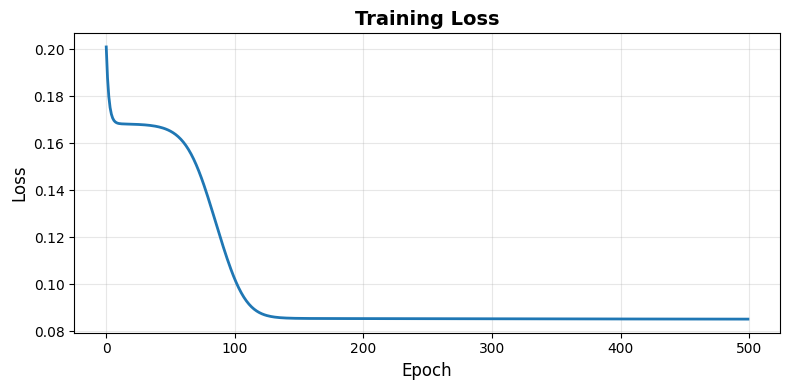


Learned 2D representations:
  cat: [0.105, -0.112]
  dog: [0.576, -0.104]
  mat: [-0.145, -0.505]
  sat: [-0.598, 0.092]
  ran: [0.079, 0.664]


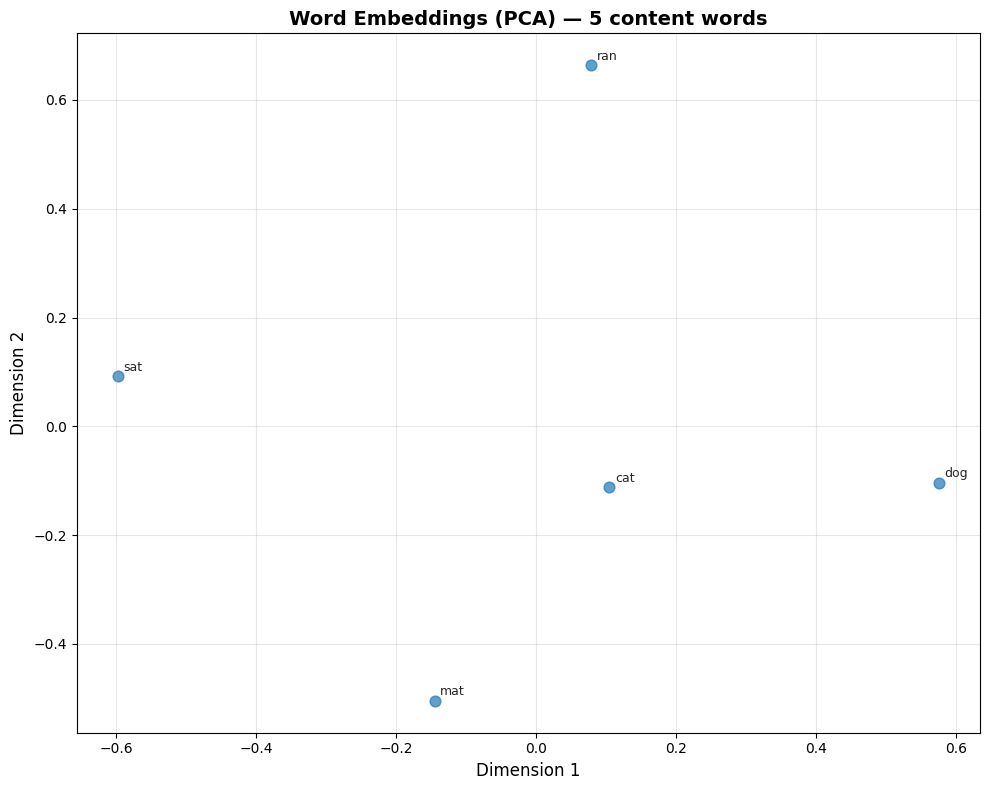

In [12]:
# Verify & train with reference implementation
ref_ae = ch04_word2vec.SimpleAutoencoder(input_dim=5, hidden_dim=2, learning_rate=0.05)

# Quick compare on first word
ref_h, ref_xhat = ref_ae.forward(tiny_onehot[0])
print(f"Reference hidden shape: {ref_h.shape}, output shape: {ref_xhat.shape}")

# Train on all 5 words for many epochs
ae_losses = []
for epoch in range(500):
    epoch_loss = 0
    for x_i in tiny_onehot:
        h, x_hat = ref_ae.forward(x_i)
        loss = ref_ae.reconstruction_loss(x_i, x_hat)
        epoch_loss += loss
        # Manual gradient step (same pattern as Ch1)
        err = x_hat - x_i
        dW_dec = np.outer(h, err)
        db_dec = err
        dh = err @ ref_ae.W_decode.T * (1 - h**2)  # tanh derivative
        dW_enc = np.outer(x_i, dh)
        db_enc = dh
        ref_ae.W_decode -= ref_ae.lr * dW_dec
        ref_ae.b_decode -= ref_ae.lr * db_dec
        ref_ae.W_encode -= ref_ae.lr * dW_enc
        ref_ae.b_encode -= ref_ae.lr * db_enc
    ae_losses.append(epoch_loss / len(tiny_onehot))

viz.plot_loss_curve(ae_losses, xlabel='Epoch')

# Extract 2D representations
hidden_reps = np.array([ref_ae.encode(x_i) for x_i in tiny_onehot])
print(f"\nLearned 2D representations:")
for word, rep in zip(tiny_vocab, hidden_reps):
    print(f"  {word}: [{rep[0]:.3f}, {rep[1]:.3f}]")

# Visualize — the network found its own 2D coordinates for each word
viz.plot_embeddings_2d(hidden_reps, tiny_vocab)

The bottleneck forced the network to invent 2D coordinates for each word. We didn't specify what the axes mean — the network chose. **This is the core idea: representations can be learned, not designed.**

Word2Vec extends this to language: instead of reconstructing the input word, we train on a different objective (predict context) that encourages the representations to capture semantic meaning.

---

## 4.4 Part B: Word2Vec (CBOW)

## 4.4b Exercise

Implement CBOW to learn word embeddings.

In [13]:
# Load WikiText-2 (small subset for training speed)
print("Loading WikiText-2...")
text = data.get_small_corpus(n_sentences=100)
print(f"Corpus length: {len(text.split())} words")

# Prepare Word2Vec training data
pairs, vocab, word2idx, idx2word = data.prepare_word2vec_data(text, window_size=2)
print(f"Vocabulary size: {len(vocab)}")
print(f"Training pairs: {len(pairs)}")

# Convert to CBOW format: (context_indices, target_idx)
cbow_pairs = []
for context_words, target_word in pairs[:1000]:  # Limit for speed
    context_indices = [word2idx[w] for w in context_words if w in word2idx]
    if target_word in word2idx and len(context_indices) > 0:
        target_idx = word2idx[target_word]
        cbow_pairs.append((context_indices, target_idx))

print(f"CBOW training pairs: {len(cbow_pairs)}")

def your_cbow_forward(context_indices, W_embed, W_out):
    """Forward pass for CBOW"""
    # TODO: Get embeddings for context words
    context_embeddings = ...
    
    # TODO: Average them (bag of words)
    context_embedding = ...
    
    # TODO: Project to vocabulary space
    logits = ...
    
    # TODO: Apply softmax
    probs = ...
    
    return context_embedding, logits, probs

# Test with small example
vocab_size = len(vocab)
embed_dim = 10
W_embed_test = np.random.randn(vocab_size, embed_dim) * 0.01
W_out_test = np.random.randn(embed_dim, vocab_size) * 0.01

test_context = cbow_pairs[0][0]
test_target = cbow_pairs[0][1]

try:
    ctx_emb, logits, probs = your_cbow_forward(test_context, W_embed_test, W_out_test)
    print(f"\nContext embedding shape: {ctx_emb.shape}")
    print(f"Logits shape: {logits.shape}")
    print(f"Probs sum: {probs.sum():.4f}")
except (AttributeError, TypeError, ValueError):
    print("[NOT IMPLEMENTED]")

Loading WikiText-2...


Corpus length: 10729 words
Vocabulary size: 2246
Training pairs: 10725
CBOW training pairs: 1000
[NOT IMPLEMENTED]


## 4.5 Verify & Compare

[NOT IMPLEMENTED] Found ... placeholder
[NOT IMPLEMENTED] Found ... placeholder

Training CBOW model...


Epoch 20/100, Loss: 5.4424


Epoch 40/100, Loss: 3.5814


Epoch 60/100, Loss: 1.6972


Epoch 80/100, Loss: 0.5989


Epoch 100/100, Loss: 0.2269

Embedding matrix shape: (2246, 50)


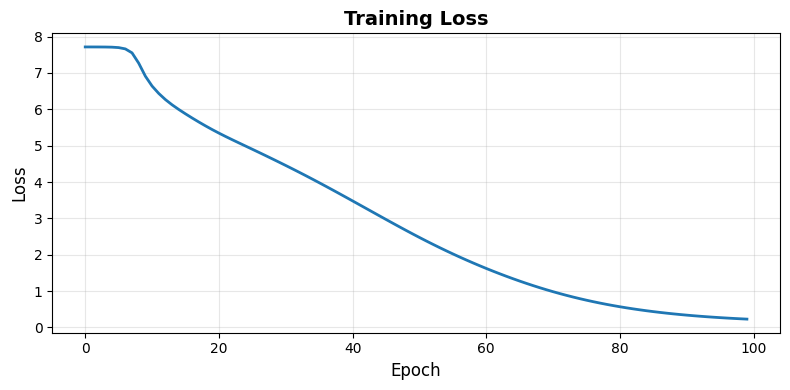

In [14]:
# Compare your CBOW forward pass against the reference
ref_ctx_emb, ref_logits, ref_probs = ch04_word2vec.cbow_forward(
    test_context, W_embed_test, W_out_test
)

try:
    your_ctx_emb, your_logits, your_probs = your_cbow_forward(test_context, W_embed_test, W_out_test)
    viz.compare(your_ctx_emb, ref_ctx_emb)
    viz.compare(your_probs, ref_probs)
except (TypeError, ValueError, AttributeError):
    print("[NOT IMPLEMENTED]")

# Train with reference implementation
print("\nTraining CBOW model...")
cbow_model, cbow_loss_history = ch04_word2vec.train_cbow(
    cbow_pairs,
    vocab_size=len(vocab),
    embed_dim=50,
    learning_rate=0.05,
    n_epochs=100
)

# Get learned embeddings
embeddings = cbow_model.get_all_embeddings()
print(f"\nEmbedding matrix shape: {embeddings.shape}")

# Plot training loss
viz.plot_loss_curve(cbow_loss_history, xlabel='Epoch')

## 4.6 Visualize

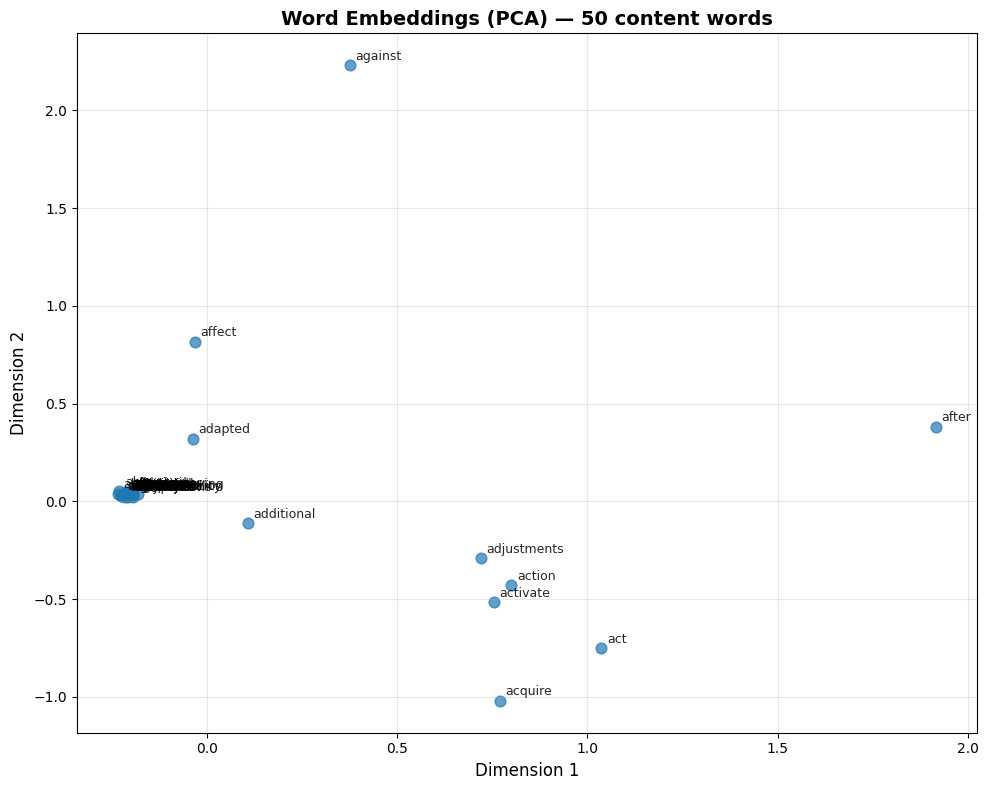


Words similar to 'abandoned':
  recommended: 0.457
  enemies: 0.395
  praising: 0.378

Words similar to 'abandons':
  club: 0.495
  focusing: 0.424
  provide: 0.405

Words similar to 'abilities':
  runs: 0.480
  missions: 0.462
  leaves: 0.459

Words similar to 'about':
  error: 0.453
  delivery: 0.413
  chicago: 0.411

Words similar to 'above':
  general: 0.487
  collaborated: 0.456
  missionary: 0.430


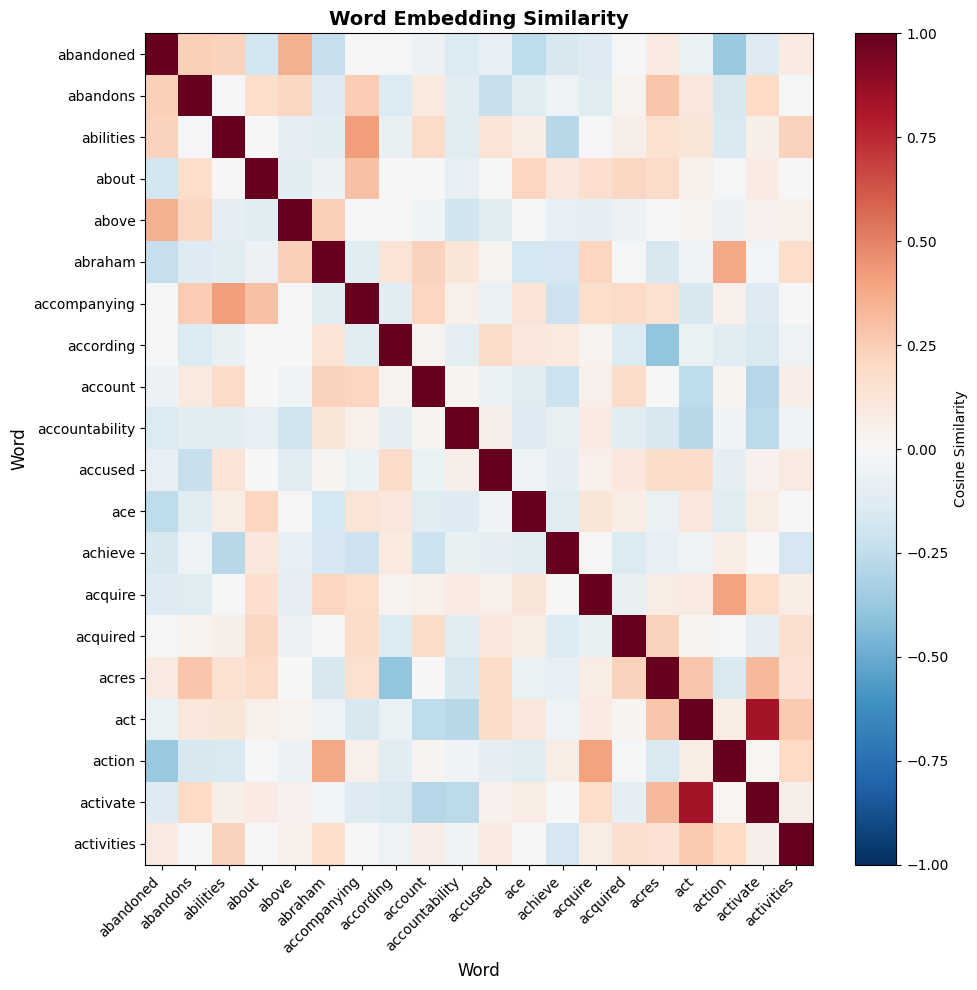

In [15]:
# Visualize embeddings in 2D — show content words only
viz.plot_embeddings_2d(embeddings, vocab, method='pca')

# Find similar words
test_words = [w for w in vocab if w.isalpha() and len(w) > 2][:5]
for test_word in test_words:
    if test_word in word2idx:
        similar = ch04_word2vec.find_similar_words(word2idx[test_word], embeddings, vocab, top_k=3)
        print(f"\nWords similar to '{test_word}':")
        for word, sim in similar:
            print(f"  {word}: {sim:.3f}")

# Show similarity heatmap — pick semantically interesting content words
content_words = [(i, w) for i, w in enumerate(vocab) if w.isalpha() and len(w) > 2][:20]
viz.plot_similarity_heatmap(embeddings, vocab, words_to_show=content_words)

**Key Takeaway:**
> We can learn meaningful word representations from data, but they don't adapt to context.

---

# Chapter 5: Multi-Layer Perceptron + Backpropagation

**Track:** Prediction  
**Question:** Can our model capture non-linear patterns?

---

## 5.1 Multi-Layer Perceptron

Logistic regression is linear — it can only draw straight-line decision boundaries. With dense embeddings carrying subtle semantic information, we need a model that can learn curves, intersections, and non-linear patterns.

We stack layers. Each layer applies a linear transformation followed by a non-linear activation function. Without the activation, stacking is pointless — multiple linear transformations collapse into a single one. The activation is what makes depth meaningful.

Backpropagation is the chain rule applied systematically through the network. Once understood, it makes training networks of any depth tractable.

---

**Forward pass** — the same linear→activate pattern, repeated. Each layer transforms the representation from the previous one.

$$\underbrace{\mathbf{z}^{(1)}}_{(H_1,)} = \underbrace{\mathbf{x}}_{(D,)}\underbrace{W^{(1)}}_{(D,\,H_1)} + \underbrace{\mathbf{b}^{(1)}}_{(H_1,)}, \qquad \mathbf{a}^{(1)} = \text{ReLU}(\mathbf{z}^{(1)}) = \max(0,\,\mathbf{z}^{(1)})$$
$$\underbrace{\mathbf{z}^{(2)}}_{(|V|,)} = \underbrace{\mathbf{a}^{(1)}}_{(H_1,)}\underbrace{W^{(2)}}_{(H_1,\,|V|)} + \underbrace{\mathbf{b}^{(2)}}_{(|V|,)}, \qquad \mathbf{p} = \text{softmax}(\mathbf{z}^{(2)})$$

**Why ReLU $= \max(0, x)$?** Its gradient is exactly 1 where the neuron fired and 0 where it did not — no saturation, no gradient shrinkage, unlike tanh or sigmoid which both approach $\pm 1$ asymptotically and produce vanishingly small gradients in deep networks. A neuron with a negative pre-activation is "dead" for that input and passes no gradient.

---

**Backward pass** — apply the chain rule in reverse order, starting from the output. The chain rule forces right-to-left order: to compute $\partial L / \partial W^{(1)}$, you need $\partial L / \partial \mathbf{a}^{(1)}$, which requires $\partial L / \partial \mathbf{z}^{(2)}$. Each layer's gradient depends on the gradient from the layer ahead of it. This is why we call it "backpropagation."

Starting from the output (the cross-entropy + softmax gradient from Ch3):
$$\frac{\partial L}{\partial \mathbf{z}^{(2)}} = \mathbf{p} - \mathbf{y}_{\text{true}}$$

Working backward through layer 2, using the cached forward values:
$$\frac{\partial L}{\partial W^{(2)}} = (\mathbf{a}^{(1)})^T \cdot \frac{\partial L}{\partial \mathbf{z}^{(2)}}, \qquad \frac{\partial L}{\partial \mathbf{a}^{(1)}} = \frac{\partial L}{\partial \mathbf{z}^{(2)}} (W^{(2)})^T$$

Working backward through the ReLU — it blocks gradient where the pre-activation was $\leq 0$:
$$\frac{\partial L}{\partial \mathbf{z}^{(1)}} = \frac{\partial L}{\partial \mathbf{a}^{(1)}} \odot \mathbf{1}[\mathbf{z}^{(1)} > 0]$$

The $\odot$ is element-wise multiplication, not matrix multiply. ReLU acts independently on each element — its derivative is a diagonal matrix of 0s and 1s, and multiplying by a diagonal matrix is the same as element-wise multiplication by its diagonal. Each forward-pass value must be cached because it is reused in the backward pass:

| Cached value | Used for |
|---|---|
| $\mathbf{x}$ | $\partial L / \partial W^{(1)} = \mathbf{x}^T \cdot \delta^{(1)}$ |
| $\mathbf{z}^{(1)}$ (pre-ReLU) | ReLU gate: $\mathbf{1}[\mathbf{z}^{(1)} > 0]$ |
| $\mathbf{a}^{(1)}$ (post-ReLU) | $\partial L / \partial W^{(2)} = (\mathbf{a}^{(1)})^T \cdot \delta^{(2)}$ |
| $W^{(2)}$ | Propagate gradient backward: $\delta^{(2)} (W^{(2)})^T$ |

---

**By hand — 2→2→2 network, one forward + backward step:**

```
Inputs:  x = [1, 0],  target class = 1  (y = [0, 1])
         W1 = [[0.5, −0.3], [0.2, 0.8]],  b1 = [0, 0]
         W2 = [[0.4, −0.4], [0.1,  0.6]],  b2 = [0, 0]

Forward:
  z1 = x @ W1          = [0.5, −0.3]
  a1 = ReLU(z1)        = [0.5,  0.0]   ← neuron 2 is dead (−0.3 < 0)
  z2 = a1 @ W2         = [0.20, −0.20]
  p  = softmax(z2)     ≈ [0.60,  0.40]
  L  = −log(0.40)      = 0.92

Backward:
  δ2  = p − y          = [ 0.60, −0.60]   (y = [0, 1])
  ∂W2 = a1.T @ δ2      = [[0.30, −0.30],
                           [0.00,  0.00]]
  ∂a1 = δ2 @ W2.T      = [ 0.48, −0.60]
  δ1  = ∂a1 ⊙ [1, 0]  = [ 0.48,  0.00]  ← dead neuron blocks gradient
```


## 5.4 Exercise

Implement ReLU activation and a simple forward pass through an MLP.

In [16]:
# Generate non-linear data (circle classification)
X, y = data.generate_nonlinear_data(n=400, noise=0.2)
print(f"Dataset: {X.shape}, Labels: {y.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

def your_relu(x):
    """ReLU activation"""
    # TODO: Return max(0, x)
    return ...

def your_relu_derivative(x):
    """Derivative of ReLU"""
    # TODO: Return 1 if x > 0, else 0
    return ...

def your_mlp_forward(x, W1, b1, W2, b2):
    """Forward pass through 2-layer MLP"""
    # TODO: First layer - linear transformation
    z1 = ...
    
    # TODO: First layer - activation
    a1 = ...
    
    # TODO: Second layer - linear transformation
    z2 = ...
    
    # TODO: Output - softmax
    probs = ...
    
    return z1, a1, z2, probs

# Test
test_x = np.array([1.0, -2.0, 0.5, -0.3])
test_relu = your_relu(test_x)
print(f"Input: {test_x}")
if test_relu is ...:
    print("[NOT YET IMPLEMENTED] Fill in your_relu() above")
else:
    print(f"ReLU: {test_relu}")
    print(f"ReLU derivative: {your_relu_derivative(test_x)}")

Dataset: (400, 2), Labels: (400,)
Class distribution: [200 200]
Input: [ 1.  -2.   0.5 -0.3]
[NOT YET IMPLEMENTED] Fill in your_relu() above


## 5.5 Verify & Compare

In [17]:
# Compare ReLU
ref_relu = ch05_mlp.relu(test_x)
viz.compare(test_relu, ref_relu)

# Train full MLP with reference implementation
print("\nTraining MLP...")
layer_sizes = [2, 16, 8, 2]  # input=2, hidden layers, output=2 classes
mlp_model, mlp_loss_history = ch05_mlp.train_mlp(
    X, y.astype(int), layer_sizes,
    activation='relu',
    learning_rate=0.01,
    n_epochs=100,
    batch_size=32
)

[NOT IMPLEMENTED] Found ... placeholder

Training MLP...
Epoch 10/100, Loss: 0.4365, Accuracy: 0.818
Epoch 20/100, Loss: 0.3038, Accuracy: 0.915


Epoch 30/100, Loss: 0.2104, Accuracy: 0.970
Epoch 40/100, Loss: 0.1569, Accuracy: 0.978
Epoch 50/100, Loss: 0.1258, Accuracy: 0.985
Epoch 60/100, Loss: 0.1024, Accuracy: 0.990
Epoch 70/100, Loss: 0.0879, Accuracy: 0.993
Epoch 80/100, Loss: 0.0732, Accuracy: 0.998
Epoch 90/100, Loss: 0.0642, Accuracy: 0.998
Epoch 100/100, Loss: 0.0577, Accuracy: 0.998


## 5.6 Visualize

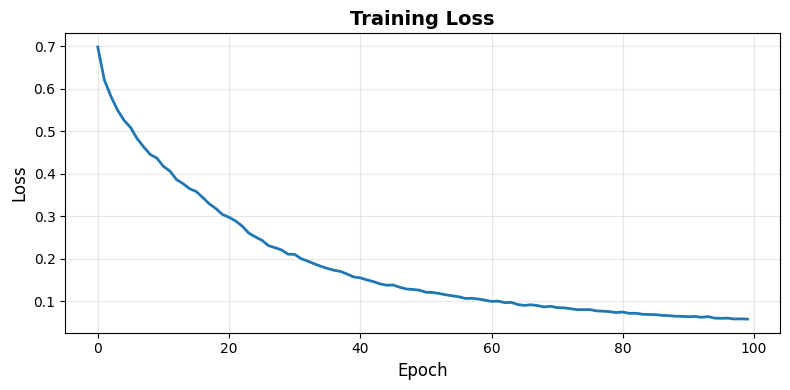

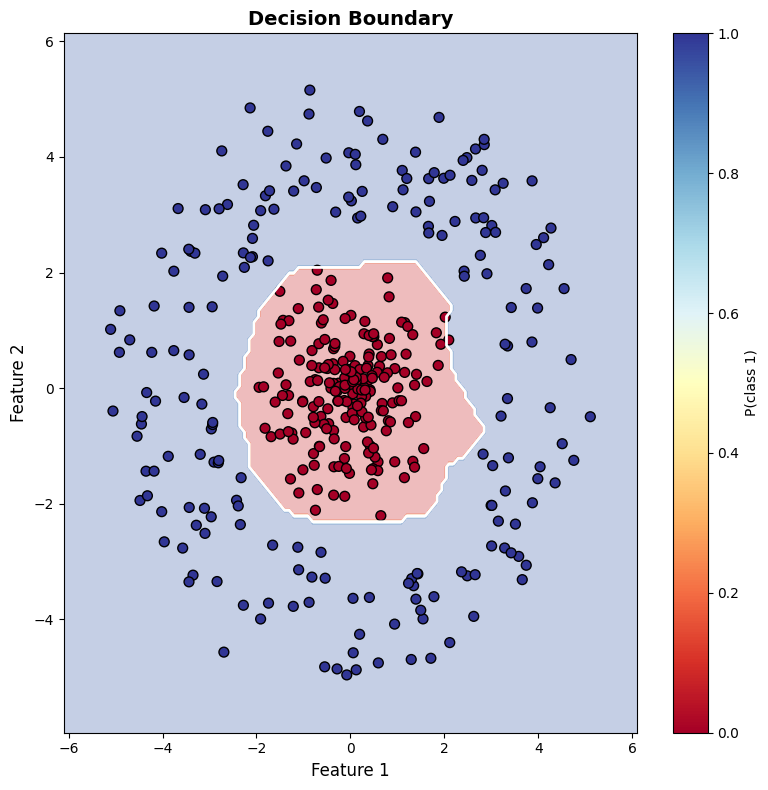

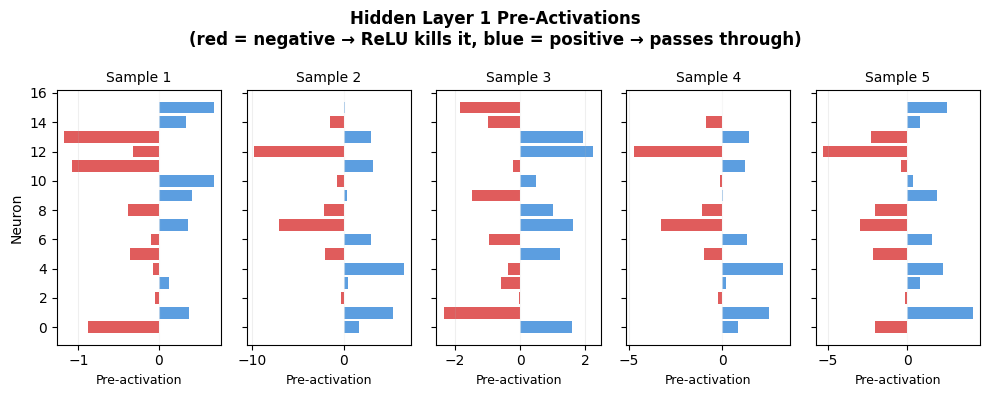


Final accuracy: 0.998


In [18]:
# Plot training loss
viz.plot_loss_curve(mlp_loss_history, xlabel="Epoch")

# Visualize decision boundary (white line = 0.5 probability threshold)
def predict_fn(X_test):
    return mlp_model.predict_class(X_test)

viz.plot_decision_boundary(predict_fn, X, y.astype(int))

# Show what the first hidden layer is doing for a few samples
viz.plot_hidden_activations(mlp_model, X[:5], layer_idx=0)

# Final accuracy
predictions = mlp_model.predict_class(X)
accuracy = np.mean(predictions == y)
print(f"\nFinal accuracy: {accuracy:.3f}")

**Key Takeaway:**
> We can learn complex functions now, but we have no way to process sequences.

---

# Chapter 6: Byte Pair Encoding (BPE)

**Track:** Representation  
**Question:** What exactly is a "word"?

---

## 6.1 Byte Pair Encoding (BPE)

Word-level vocabulary has a fundamental problem: what happens when the model encounters a word it has never seen? "Unfriendliness" might not appear in a 50,000-word vocabulary, leaving the model with no representation for it at all. This is the out-of-vocabulary (OOV) problem.

Character-level tokenization solves OOV but loses meaning — the model works character-by-character and must rediscover word structure from scratch, producing very long sequences. BPE finds the middle ground: common words stay whole ("the", "and"), while rare words break into meaningful subword pieces ("un" + "friend" + "li" + "ness"). From this point on, our model predicts the next **token**, not the next word.

---

**BPE Algorithm:**

1. Initialize: split every word into individual characters; append `</w>` to mark word boundaries
2. While vocabulary size $|V|$ is below the target:
   - Count all adjacent token pairs in the corpus
   - Find the most frequent pair $(t_i, t_j)$
   - Merge: replace every occurrence of $t_i\ t_j$ with the joined token $t_it_j$
   - Add the merged token to $V$

The `</w>` marker keeps word boundaries intact. Without it, the final character of "the" could merge with the first character of the next word, and "the" and "there" would share token sequences inappropriately.

**Concrete trace — 3 merge iterations on "hello world":**

| Step | Corpus | Merge applied |
|------|--------|--------------|
| Start | `h e l l o </w>  w o r l d </w>` | — |
| Merge 1 | `h e ll o </w>  w o r l d </w>` | `(l, l)` → `ll` |
| Merge 2 | `h e ll o</w>  w o r l d </w>` | `(o, </w>)` → `o</w>` |
| Merge 3 | `h e ll o</w>  w o r ld </w>` | `(l, d)` → `ld` |

After many iterations on a large corpus, common words become single tokens; rare words decompose into familiar subword pieces.

The algorithm is greedy: at every step, find the one merge that removes the most redundancy, apply it everywhere, repeat. The training corpus encodes what is common in the language; the learned merges encode what patterns to remember.

Linguistic structure emerges naturally. Substrings like "un-", "-ing", "-ness" appear across many different words. Their character-pair sequences get merged repeatedly until they become single tokens — because frequency across the whole corpus reflects genuine linguistic regularity.

Any new word — even one never seen in training — can be tokenized by replaying the learned merges in order. "Unfriendliness" → "un" + "friend" + "li" + "ness" → all known pieces. OOV is solved.

**Design choice — why not just use characters or whole words?**

| Strategy | Vocabulary size | Sequence length | OOV? |
|---|---|---|---|
| Characters | ~100 | Very long | None |
| Words | 50k–500k | Short | Common |
| **BPE** (subwords) | **~30k–50k** | **Moderate** | **None** |

BPE hits the sweet spot: short sequences (unlike characters), open vocabulary (unlike words).

**Compression ratio** — average tokens per word:
$$r = \frac{n_{\text{words}}}{n_{\text{tokens}}}$$

A ratio below 1 means more tokens than words (character-like behavior). Near 1 means words are mostly kept whole. Real BPE tokenizers land around 0.7–0.9 on typical English text.


## 6.4 Exercise

Implement the core BPE operations.

In [19]:
# Load WikiText-2 for realistic text
print("Loading WikiText-2...")
text = data.get_small_corpus(n_sentences=50)
print(f"Text sample: {text[:200]}...")
print(f"Text length: {len(text)} characters")

def your_get_pair_frequencies(word_splits):
    """Count frequencies of adjacent token pairs"""
    from collections import Counter
    
    pair_freqs = Counter()
    
    for word, freq in word_splits.items():
        symbols = word.split()
        
        for i in range(len(symbols) - 1):
            # TODO: Count each adjacent pair, weighted by word frequency
            # pair = (symbols[i], symbols[i+1])
            # pair_freqs[pair] += freq
            ...
    
    return pair_freqs

def your_merge_pair(word, pair):
    """Merge a pair in a word representation"""
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    
    # TODO: Replace the space-separated bigram with the merged token
    # new_word = word.replace(bigram, replacement)
    new_word = ...
    
    return new_word

# Test
test_word_splits = {'h e l l o </w>': 5, 'w o r l d </w>': 3}
test_pairs = your_get_pair_frequencies(test_word_splits)
print(f"\nPairs found: {dict(test_pairs)}")

test_merge = your_merge_pair('h e l l o </w>', ('l', 'l'))
print(f"After merging ('l', 'l'): {test_merge}")

Loading WikiText-2...
Text sample: = Valkyria Chronicles III = Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is...
Text length: 41726 characters

Pairs found: {}
After merging ('l', 'l'): Ellipsis


## 6.5 Verify & Compare

In [20]:
# Compare pair frequencies
ref_pairs = ch06_bpe.get_pair_frequencies(test_word_splits)
viz.compare(dict(test_pairs), dict(ref_pairs))

# Train full BPE with reference implementation
print("\nTraining BPE tokenizer...")
bpe = ch06_bpe.BytePairEncoding(vocab_size=500)
bpe.train(text)

print(f"Learned vocabulary size: {len(bpe.vocab)}")
print(f"Number of merges: {len(bpe.merges)}")
print(f"Sample merges: {bpe.merges[:10]}")

[FAIL] Keys don't match!
   Your keys: set()
   Reference keys: {('w', 'o'), ('l', 'l'), ('r', 'l'), ('e', 'l'), ('h', 'e'), ('d', '</w>'), ('l', 'o'), ('o', 'r'), ('l', 'd'), ('o', '</w>')}

Training BPE tokenizer...


Learned vocabulary size: 500
Number of merges: 431
Sample merges: [('e', '</w>'), ('t', 'h'), ('s', '</w>'), ('d', '</w>'), ('th', 'e</w>'), ('n', '</w>'), ('e', 'r'), ('t', '</w>'), (',', '</w>'), ('i', 'n')]


## 6.6 Visualize

Tokenized (24 tokens from 9 words):
  the</w> | qu | ick</w> | b | row | n</w> | f | o | x | </w> | j | u | m | p | s</w> | over</w> | the</w> | l | a | z | y</w> | d | o | g</w>


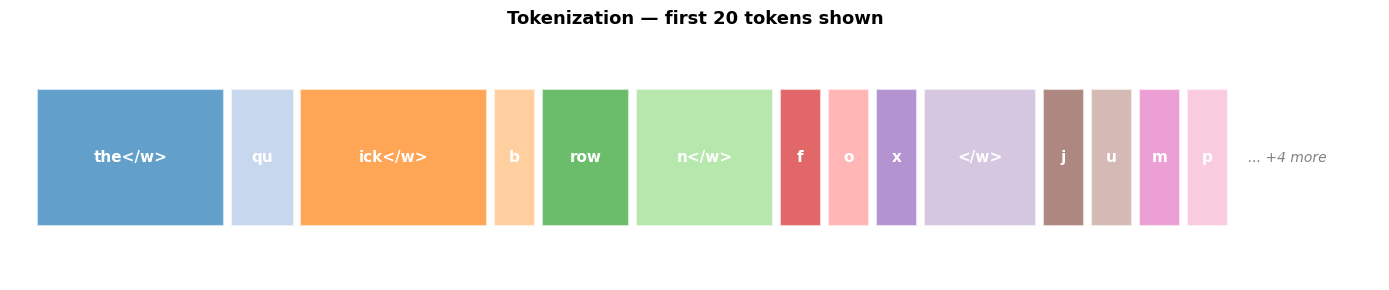

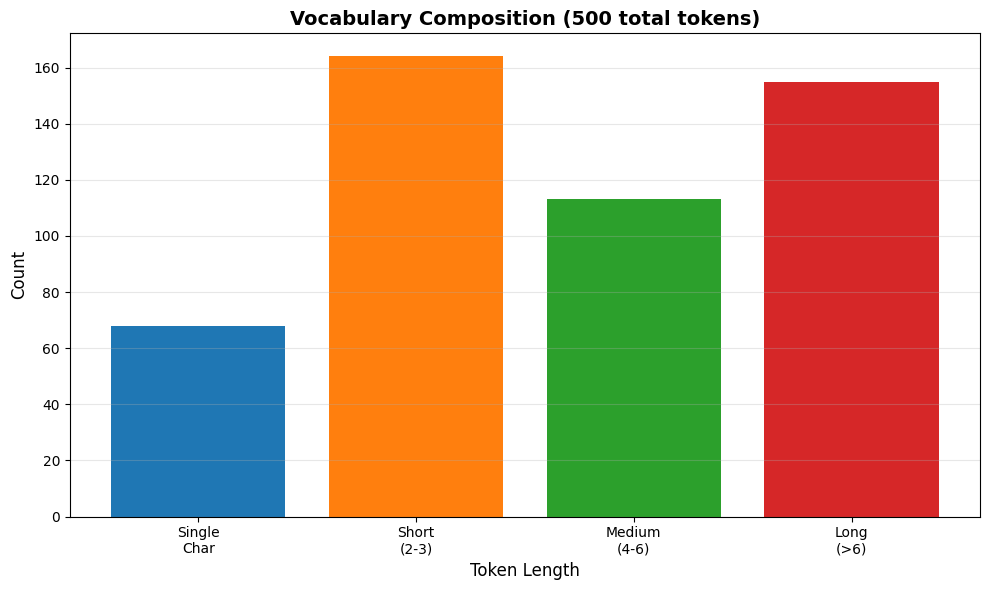

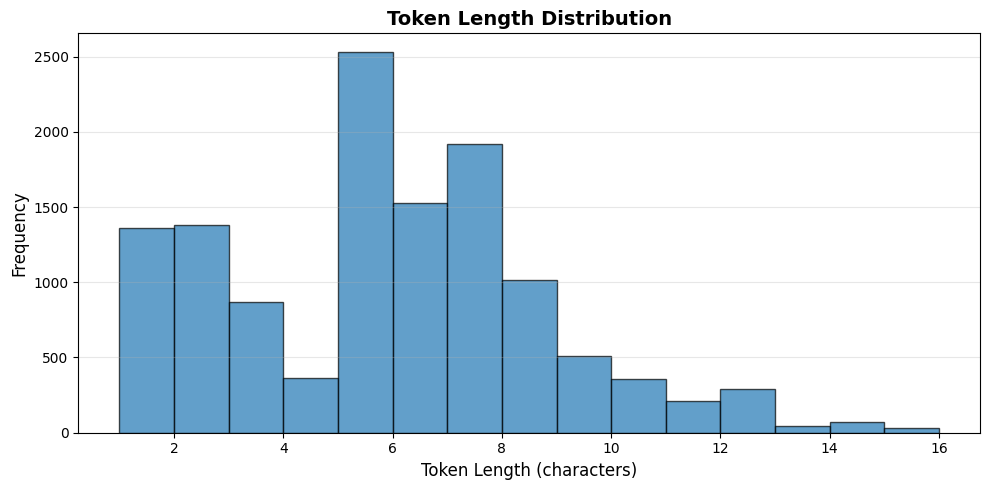


=== Tokenization Comparison ===

WORD:
  Tokens: 7704
  Vocabulary size: 1904
  Sample: = | Valkyria | Chronicles | III | = | Senjō | no | Valkyria | 3 | :...

CHARACTER:
  Tokens: 41726
  Vocabulary size: 94
  Sample: = | ▁ | V | a | l | k | y | r | i | a...

BPE:
  Tokens: 12469
  Vocabulary size: 500
  Sample: =</w> | valkyria</w> | chronicles</w> | iii</w> | =</w> | sen | j | ō | </w> | no</w>...


In [21]:
# Tokenize sample text
sample_text = "The quick brown fox jumps over the lazy dog"
tokens = bpe.encode(sample_text)

viz.plot_tokenization(sample_text, tokens)

# Analyze vocabulary composition
viz.plot_vocab_composition(bpe.vocab)

# Analyze token lengths
full_tokens = bpe.encode(text)
viz.plot_token_lengths(full_tokens)

# Compare tokenization strategies
comparison = ch06_bpe.compare_tokenizations(text)
print("\n=== Tokenization Comparison ===")
for strategy, stats in comparison.items():
    print(f"\n{strategy.upper()}:")
    print(f"  Tokens: {stats['n_tokens']}")
    print(f"  Vocabulary size: {stats['vocab_size']}")
    print(f"  Sample: {' | '.join([str(t) for t in stats['sample'][:10]])}...")

**Key Takeaway:**
> We now have an open vocabulary. No word is truly unknown.

---

## Part I Summary

We now have a complete pipeline:
1. Raw text → BPE tokenizer → token IDs
2. Token IDs → embeddings (Word2Vec-style dense vectors)
3. Embeddings → MLP → softmax → probability over next token

This is a real, trainable language model. But it treats its input as an unordered bag of tokens. "The cat sat on the mat" and "mat the the on sat cat" produce the same prediction.

The model has no concept of sequence, order, or structure. **That is what Part II solves.**

In Part II (coming in a separate notebook), we introduce:
- **RNNs**: Process sequences with memory
- **LSTMs**: Better long-term memory
- **Attention**: Look at all positions, not just a compressed state
- **Transformers**: Attention is all you need
- **Autoregressive generation**: Turn predictions into actual text

---

## Next Steps

Continue to Part II: `part2_sequences_to_transformers.ipynb` (coming soon)

Or experiment here:
- Train Word2Vec on the full WikiText-2 corpus
- Build a larger BPE vocabulary
- Stack more layers in the MLP
- Try different activation functions (tanh, sigmoid)
- Implement skip-gram instead of CBOW